<img src = "https://drive.google.com/uc?export=view&id=14reVO1X6LsjqJ3cFgoeHxxddZVGfZn3t" alt = "Encabezado MLDS" width = "100%">  </img>

 # MACROPULSE MODEL
 ## Optimización de Portafolios con LSTM, Sentimiento de la FED y dinámica de ciclos económicos

**Integrantes:**
- Adriana Valderrama — adrianavalderrama11@gmail.com
- Luis Felipe Tolosa — ltolosas@unal.edu.co
- Michael Betancourt — msbetancourtge@unal.edu.co

---
**Objetivo:** Predecir retornos mensuales de 9 activos usando un LSTM que integra señales NLP de la FED, variables macroeconómicas (niveles + deltas) y retornos históricos, para alimentar un optimizador de portafolios de Markowitz.

# **FASE 1**
# **Entendimiento del Negocio y Carga de Datos**
---

## 1. Trasfondo del Negocio

**Dominio:** Finanzas cuantitativas y Gestión de portafolios de inversión.

**Beneficiarios:** Inversionistas que buscan asignar capital entre múltiples clases de activos (tecnología, energía, consumo defensivo, utilities, banca y renta fija) de forma sistemática y fundamentada.

**Problema del dominio:** La asignación de activos tradicionalmente se basa en retornos históricos y covarianzas estáticas, ignorando dos señales que mueven los mercados:

1. **Los ciclos macroeconómicos rotan, qué sectores generan valor.** En expansión, los cíclicos (tech, energía) lideran; en contracción, los defensivos (utilities, bonos, consumo básico) protegen el capital. Un portafolio que no se adapta al régimen macro deja rendimiento sobre la mesa o asume riesgo innecesario.

2. **La postura de la Reserva Federal amplifica o amortigua estos ciclos.** Un tono hawkish encarece el crédito y castiga a growth stocks; un tono dovish inyecta liquidez y favorece activos de riesgo. Esta señal cualitativa, contenida en los comunicados FOMC, no se captura con datos numéricos tradicionales.

El problema no consiste simplemente en predecir precios, sino en entender cómo el mercado responde a un entorno dinámico compuesto por condiciones económicas, decisiones de política monetaria y el comportamiento reciente de los activos. El inversionista promedio no tiene herramientas para procesar simultáneamente estas tres dimensiones y tomar decisiones de asignación óptima cada mes.

## 2. Objetivo del Proyecto

Desarrollar **MacroPulse**, un sistema de predicción de retornos mensuales basado en un LSTM multi-output que genera estimaciones *forward-looking* — anticipando el comportamiento futuro de los activos incorporando no solo su historia, sino también el contexto económico y monetario en el que operan.

El modelo integra tres fuentes clave de información:
- **Datos de mercado:** Retornos históricos mensuales de 9 activos (AMD, GOOGL, AGG, XOM, JNJ, WMT, CM, DUK, BNS).
- **Variables macroeconómicas:** Inflación, desempleo, producción industrial, curva de rendimiento, VIX, spreads crediticios, M2 y petróleo — en niveles y deltas (dirección del cambio).
- **Señales de política monetaria:** Hawkish Index construido mediante NLP (FinBERT) a partir de los comunicados FOMC de la FED.

Las predicciones alimentan un optimizador de portafolios de Markowitz con covarianza robusta (Ledoit-Wolf) para generar pesos de inversión óptimos mensualmente, maximizando el ratio de Sharpe bajo restricciones de diversificación.

## 3. ¿Por qué un LSTM?

Un LSTM es especialmente adecuado para este problema porque pertenece a la familia de redes neuronales recurrentes diseñadas para datos secuenciales, donde el orden temporal y la historia de las variables son fundamentales. A diferencia de modelos tradicionales (regresiones, redes densas), el LSTM captura:

**Dependencias temporales:** El comportamiento del mercado depende de cómo *evolucionan* las variables, no solo de su valor actual. Una inflación alta no tiene el mismo efecto si viene bajando que si viene subiendo. Un tono hawkish de la FED es más relevante si representa un cambio reciente frente a una tendencia estable.

**Efectos rezagados:** Cambios en la política monetaria afectan al mercado con retraso; la inflación impacta el consumo gradualmente. **El LSTM aprende estos patrones de retraso de forma implícita**, sin necesidad de especificarlos manualmente. Al trabajar con variables macro y sus rezagos, la ventana de 6 meses permite que las señales tengan mayor varianza de información y potencialmente mayor poder predictivo sobre ciclos de negocio.

**Persistencia y cambios de régimen:** Los mercados se mueven en fases — períodos de alta o baja volatilidad, entornos monetarios restrictivos o expansivos. El LSTM identifica patrones persistentes y detecta transiciones entre estados, clave para modelar tanto retornos como riesgo.

**Interacciones no lineales:** El impacto del desempleo puede depender del nivel de inflación; el efecto del Hawkish Index varía según el contexto de tasas de interés. El LSTM captura estas interacciones sin necesidad de definirlas explícitamente.

**Integración de señales heterogéneas:** El modelo combina datos numéricos (inflación, retornos) con datos derivados de texto (Hawkish Index), procesándolos como una secuencia conjunta donde aprende cómo estas señales evolucionan e interactúan para influir en el mercado.

En este contexto, el modelo no busca "adivinar" el mercado, sino proporcionar mejores insumos para la toma de decisiones en la construcción de portafolios — transformando un enfoque tradicional basado en promedios históricos en un sistema más dinámico, contextual y alineado con el comportamiento real de los mercados.

## 4. Valor para el Inversionista

- **Decisiones basadas en datos, no en intuición.** El modelo cuantifica objetivamente el impacto del ciclo macro y la postura de la FED sobre cada sector, eliminando sesgos cognitivos.
- **Rotación sectorial anticipada.** Al incorporar deltas macroeconómicos (dirección del cambio), el modelo detecta transiciones de régimen antes de que se reflejen completamente en los precios.
- **Diversificación inteligente.** La restricción de peso máximo (25% por activo) y la covarianza shrinkage evitan concentración excesiva.
- **Operación mensual reproducible.** El pipeline se ejecuta cada mes con datos actualizados de la FED, FRED y Yahoo Finance, generando una recomendación accionable.
- **Transparencia.** El Permutation Importance permite al inversionista entender qué variables impulsan las recomendaciones, generando confianza en el modelo.

## 5. Alcance del Proyecto

**¿Qué solución implementamos?** Un LSTM multi-output global que recibe ventanas de 6 meses de 35 features (9 retornos + 4 NLP + 22 macro) y predice simultáneamente los retornos del mes siguiente para 9 activos.

**¿Qué se hará?**
1. Construir un corpus NLP de ~200 comunicados FOMC (2000–2024) combinando HuggingFace y scraping directo de la FED.
2. Extraer sentimiento financiero y un Hawkish Index con FinBERT.
3. Descargar y transformar 13 series macroeconómicas de FRED en 22 features (niveles + deltas + tasas de cambio).
4. Entrenar un LSTM global con grid search sobre ~250 meses de datos (2003–2024).
5. Evaluar con métricas de magnitud (MSE, MAE, R²), dirección (Cosine Similarity, Directional Accuracy) y distribución (KL Divergence).
6. Generar asignaciones óptimas de portafolio vía Markowitz y comparar contra un benchmark equal-weight.
7. Cuantificar la importancia de cada feature con Permutation Importance.

**¿Cómo utilizará el inversionista el producto?** Mensualmente, ejecuta el notebook con datos actualizados. El sistema produce predicciones de retorno por activo, pesos óptimos de portafolio y un diagnóstico de qué variables macro están impulsando las recomendaciones.

---

## **Carga de Datos**

In [1]:
#!pip install pypdf yfinance transformers torch pandas beautifulsoup4 requests pandas-datareader datasets scikit-learn scipy
!pip install pypdf yfinance transformers pandas-datareader datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 11.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings, datetime, math, random
import io, re, time, requests, sys
from urllib.parse import urljoin
from bs4 import BeautifulSoup
import pypdf

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### 2. Extracción del Corpus FOMC (Fuente Dual: HuggingFace + Scraping Directo)
Combinamos dos fuentes para máxima cobertura:
1. **HuggingFace** (`vtasca/fomc-statements-minutes`): Corpus histórico limpio (2000-2025).
2. **Scraping directo de la FED**: Permite actualizar mes a mes con los statements más recientes.

Deduplicamos por fecha priorizando HuggingFace (texto desde HTML es más limpio que extracción de PDF).

In [3]:
# ===== FUENTE 1: HuggingFace (Corpus histórico) =====
from datasets import load_dataset

print("Descargando corpus FOMC desde HuggingFace...")
ds = load_dataset("vtasca/fomc-statements-minutes", split="train")
df_hf = ds.to_pandas()
df_hf = df_hf[df_hf["Type"] == "Statement"].copy()
df_hf["date"] = pd.to_datetime(df_hf["Date"])
df_hf = df_hf.rename(columns={"Text": "content"})
df_hf["source"] = "huggingface"
df_hf = df_hf[["date", "content", "source"]].sort_values("date").reset_index(drop=True)
df_hf = df_hf[df_hf["date"] >= "2000-01-01"]
print(f"  HuggingFace: {len(df_hf)} statements")

# ===== FUENTE 2: Scraping directo de la FED (Para actualizaciones mensuales) =====
HEADERS = {"User-Agent": "Mozilla/5.0"}
BASE = "https://www.federalreserve.gov"
CAL_URL = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
STATEMENT_PDF_RE = re.compile(
    r"^https?://www\.federalreserve\.gov/monetarypolicy/files/monetary(\d{8})a(\d+)\.pdf$",
    re.IGNORECASE
)

def extract_text_from_pdf_bytes(pdf_bytes):
    reader = pypdf.PdfReader(io.BytesIO(pdf_bytes))
    return "\n".join([page.extract_text() or "" for page in reader.pages]).strip()

def keep_statement_only(raw_text):
    low = raw_text.lower()
    headers = ["implementation note", "implementation notes", "information received"]
    for h in headers:
        pos = low.find(h)
        if pos != -1:
            return raw_text[:pos].strip()
    return raw_text.strip()

def download_fed_corpus_full():
    print("Escaneando calendario de la FED en busca de PDFs...")
    try:
        r = requests.get(CAL_URL, headers=HEADERS, timeout=30)
        soup = BeautifulSoup(r.text, "html.parser")
        urls = sorted(set([
            urljoin(BASE, a["href"].strip())
            for a in soup.find_all("a", href=True)
            if STATEMENT_PDF_RE.match(urljoin(BASE, a["href"].strip()))
        ]))
        rows = []
        print(f"  Descargando {len(urls)} PDFs...")
        with requests.Session() as session:
            for url in urls:
                try:
                    res = session.get(url, headers=HEADERS, timeout=30)
                    raw_text = extract_text_from_pdf_bytes(res.content)
                    clean_text = keep_statement_only(raw_text)
                    rows.append({
                        "date": re.search(r"(\d{8})", url).group(1),
                        "content": clean_text, "source": "fed_scraping"
                    })
                    time.sleep(0.1)
                except:
                    continue
        df_out = pd.DataFrame(rows)
        df_out["date"] = pd.to_datetime(df_out["date"])
        print(f"  Scraping directo: {len(df_out)} statements")
        return df_out
    except Exception as e:
        print(f"  Scraping falló ({e}), usando solo HuggingFace.")
        return pd.DataFrame(columns=["date", "content", "source"])

df_direct = download_fed_corpus_full()

# ===== LIMPIEZA UNIFICADA: aplicar keep_statement_only a AMBAS fuentes =====
def clean_statement_text(text):
    """Limpieza consistente para statements de cualquier fuente."""
    if not isinstance(text, str):
        return ""
    # Cortar implementation notes y voting records
    text = keep_statement_only(text)
    # Eliminar líneas de votación ("Voting for/against", "Jerome H. Powell, Chair")
    lines = text.split("\n")
    clean_lines = []
    for line in lines:
        low = line.lower().strip()
        if any(k in low for k in ["voting for", "voting against", "chair",
                                    "vice chair", "governor", "president",
                                    "board of governors", "dissenting"]):
            continue
        clean_lines.append(line)
    text = "\n".join(clean_lines)
    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Aplicar a AMBAS fuentes ANTES del merge
df_hf["content"] = df_hf["content"].apply(clean_statement_text)
df_direct["content"] = df_direct["content"].apply(clean_statement_text)

# Merge
df_fed = pd.concat([df_hf, df_direct], ignore_index=True)
df_fed["date_key"] = df_fed["date"].dt.to_period("M")
df_fed = df_fed.sort_values(["date_key", "source"])
df_fed = df_fed.drop_duplicates(subset="date_key", keep="first")
df_fed = df_fed.drop(columns="date_key").sort_values("date").reset_index(drop=True)

# Verificar consistencia: longitud promedio por fuente
for src in df_fed["source"].unique():
    subset = df_fed[df_fed["source"] == src]
    avg_len = subset["content"].str.len().mean()
    print(f"  {src}: {len(subset)} docs | longitud promedio: {avg_len:.0f} chars")

print(f"\nCorpus FOMC final: {len(df_fed)} statements")


Descargando corpus FOMC desde HuggingFace...


README.md: 0.00B [00:00, ?B/s]

communications.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/463 [00:00<?, ? examples/s]

  HuggingFace: 223 statements
Escaneando calendario de la FED en busca de PDFs...
  Descargando 43 PDFs...
  Scraping directo: 43 statements
  huggingface: 171 docs | longitud promedio: 1150 chars
  fed_scraping: 43 docs | longitud promedio: 4964 chars

Corpus FOMC final: 214 statements


## 3. Extracción de Características NLP (FinBERT)
Debido a que los modelos de Deep Learning requieren entradas numéricas, en vez de entrenar un modelo desde cero con los pocos documentos disponibles, utilizaremos **FinBERT**, que es un modelo *Transformer* preentrenado específicamente en textos financieros.
Extraemos dos representaciones numéricas de cada comunicado de la FED:
1. **Sentimiento:** Probabilidades de que el texto sea Positivo, Negativo o Neutral.
2. **Embeddings:** Un vector denso de 768 dimensiones que captura el contexto semántico profundo del comunicado.

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analizando statements de la FED con FinBERT...
NLP completado. 214 statements analizados.


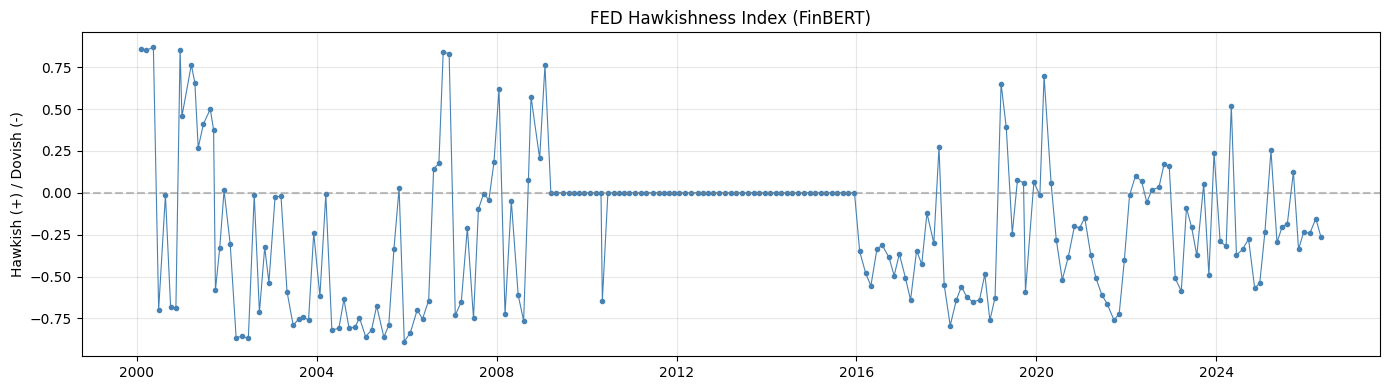


ValidaciÃ³n del Hawkish Index vs contexto histÃ³rico:
  2009-2013: Valores negativos (dovish) â€” era QE con tasas en cero.
  2017-2018: Territorio positivo (hawkish) â€” la FED estaba subiendo tasas.
  2020:      CaÃ­da abrupta a dovish â€” recorte de emergencia por COVID.
  2022-2024: Mayor varianza y seÃ±ales hawkish â€” ciclo de tightening mÃ¡s agresivo en dÃ©cadas.


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
sentiment_model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

import re

def split_into_chunks(text, max_chars=450):
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
    chunks, current = [], ""
    for s in sentences:
        if len(current) + len(s) > max_chars and current:
            chunks.append(current.strip())
            current = s
        else:
            current = current + " " + s if current else s
    if current.strip():
        chunks.append(current.strip())
    return [c for c in chunks if len(c) > 80]

def extract_finbert_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.33, 0.33, 0.33, 0.0
    chunks = split_into_chunks(text, max_chars=450)
    if not chunks:
        chunks = [text[:500]]
    all_scores = []
    for chunk in chunks:
        inputs = tokenizer(chunk, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = sentiment_model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()
        pos, neg, neu = probs[0], probs[1], probs[2]
        extremeness = abs(neg - pos)
        all_scores.append((pos, neg, neu, extremeness))
    total_weight = sum(s[3] + 0.01 for s in all_scores)
    pos_agg = sum(s[0] * (s[3] + 0.01) for s in all_scores) / total_weight
    neg_agg = sum(s[1] * (s[3] + 0.01) for s in all_scores) / total_weight
    neu_agg = sum(s[2] * (s[3] + 0.01) for s in all_scores) / total_weight
    return pos_agg, neg_agg, neu_agg, neg_agg - pos_agg

nlp_cols = ["finbert_positive", "finbert_negative", "finbert_neutral", "hawkish_index"]
df_fed = df_fed.drop(columns=[c for c in nlp_cols if c in df_fed.columns], errors="ignore")

print("Analizando statements de la FED con FinBERT...")
sentiments = []
for _, row in df_fed.iterrows():
    p, n, ne, h = extract_finbert_sentiment(row["content"])
    sentiments.append({"finbert_positive": p, "finbert_negative": n,
                       "finbert_neutral": ne, "hawkish_index": h})

df_fed[nlp_cols] = pd.DataFrame(sentiments, index=df_fed.index)
print(f"NLP completado. {len(df_fed)} statements analizados.")

plt.figure(figsize=(14, 4))
plt.plot(df_fed["date"], df_fed["hawkish_index"], marker="o", markersize=3, linewidth=0.8, color="steelblue")
plt.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
plt.title("FED Hawkishness Index (FinBERT)"); plt.ylabel("Hawkish (+) / Dovish (-)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\nValidaciÃ³n del Hawkish Index vs contexto histÃ³rico:")
print("  2009-2013: Valores negativos (dovish) â€” era QE con tasas en cero.")
print("  2017-2018: Territorio positivo (hawkish) â€” la FED estaba subiendo tasas.")
print("  2020:      CaÃ­da abrupta a dovish â€” recorte de emergencia por COVID.")
print("  2022-2024: Mayor varianza y seÃ±ales hawkish â€” ciclo de tightening mÃ¡s agresivo en dÃ©cadas.")

### 4. Datos de Mercado (Yahoo Finance)
**Tickers (sectores):**
- `AMD` - Semiconductores / TecnologÃ­a
- `GOOGL` - Big Tech / Comunicaciones
- `AGG` - Bonos Agregados (ETF renta fija)
- `XOM` - EnergÃ­a / PetrÃ³leo
- `JNJ` - Salud / FarmacÃ©utica
- `WMT` - Consumo bÃ¡sico / Retail
- `CM` - Banca canadiense
- `DUK` - Utilities / EnergÃ­a elÃ©ctrica
- `BNS` - Banca canadiense


In [5]:
import yfinance as yf

TICKERS = ["AMD", "GOOGL", "AGG", "XOM", "JNJ", "WMT", "CM", "DUK", "BNS"]
START_DATE, END_DATE = "2003-01-01", "2024-12-31"

ticker_info = {
    "AMD":   "Semiconductores / TecnologÃ­a",
    "GOOGL": "Big Tech / Comunicaciones",
    "AGG":   "Bonos Agregados (ETF Renta Fija)",
    "XOM":   "EnergÃ­a / PetrÃ³leo",
    "JNJ":   "Salud / FarmacÃ©utica",
    "WMT":   "Consumo BÃ¡sico / Retail",
    "CM":    "Banca Canadiense",
    "DUK":   "Utilities / EnergÃ­a ElÃ©ctrica",
    "BNS":   "Banca Canadiense",
}

print(f"Descargando {len(TICKERS)} activos ({START_DATE} â†’ {END_DATE})...")
print("=" * 70)

frames = {}
for t in TICKERS:
    try:
        raw = yf.download(t, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        if not raw.empty:
            frames[t] = raw["Close"]
            print(f"  âœ“ {t} ({ticker_info[t]}): {len(raw)} dÃ­as, "
                  f"{raw.index[0].strftime('%Y-%m-%d')} â†’ {raw.index[-1].strftime('%Y-%m-%d')}")
        else:
            print(f"  âœ— {t}: sin datos")
    except Exception as e:
        print(f"  âœ— {t}: ERROR - {e}")

df_prices = pd.DataFrame(frames)
df_prices.index.name = "date"
df_prices = df_prices.reset_index()
df_prices["date"] = pd.to_datetime(df_prices["date"])
df_prices = df_prices.sort_values("date")

print(f"\nâœ… {len(df_prices)} dÃ­as descargados")
print(f"\nNaN por ticker:")
print(df_prices[TICKERS].isna().sum())


Descargando 9 activos (2003-01-01 â†’ 2024-12-31)...
  âœ“ AMD (Semiconductores / TecnologÃ­a): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30
  âœ“ GOOGL (Big Tech / Comunicaciones): 5126 dÃ­as, 2004-08-19 â†’ 2024-12-30
  âœ“ AGG (Bonos Agregados (ETF Renta Fija)): 5350 dÃ­as, 2003-09-29 â†’ 2024-12-30
  âœ“ XOM (EnergÃ­a / PetrÃ³leo): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30
  âœ“ JNJ (Salud / FarmacÃ©utica): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30
  âœ“ WMT (Consumo BÃ¡sico / Retail): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30
  âœ“ CM (Banca Canadiense): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30
  âœ“ DUK (Utilities / EnergÃ­a ElÃ©ctrica): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30
  âœ“ BNS (Banca Canadiense): 5536 dÃ­as, 2003-01-02 â†’ 2024-12-30

âœ… 5536 dÃ­as descargados

NaN por ticker:
AMD        0
GOOGL    410
AGG      186
XOM        0
JNJ        0
WMT        0
CM         0
DUK        0
BNS        0
dtype: int64


### 5. Variables MacroeconÃ³micas (FRED)

El Hawkish Index captura la *percepciÃ³n* de la FED, pero el modelo necesita cruzarla con la *realidad cuantitativa* del ciclo econÃ³mico. Descargamos 13 series de **FRED** vÃ­a `pandas_datareader` y las transformamos en 22 features organizadas en tres categorÃ­as:

**Niveles (9 vars):** Estado actual del ciclo.
- `UNRATE` (desempleo), `FEDFUNDS` (tasa de polÃ­tica monetaria), `T10Y2Y` (spread de curva 10Y-2Y, predictor de recesiÃ³n), `DGS10` (rendimiento 10Y, costo de capital), `BAA10Y` (spread corporativo, estrÃ©s financiero), `VIXCLS` (volatilidad implÃ­cita), `UMCSENT` (sentimiento del consumidor), `DCOILWTICO` (petrÃ³leo WTI), `ICSA` (solicitudes iniciales de desempleo).

**Deltas (9 vars):** DirecciÃ³n del cambio â€” tan importante como el nivel. Desempleo al 5% bajando (recuperaciÃ³n) â‰  subiendo (deterioro). Calculados como `diff()` mensual de cada variable en nivel.

**Tasas de cambio (4 vars):** Variables que ya son derivadas. `Inflation` (pct_change del CPI), `INDPRO_Growth` (producciÃ³n industrial), `M2_Growth` (liquidez monetaria), `DGORDER_Growth` (pedidos de bienes durables).

Se alinean a frecuencia mensual (`ME`) y se unen al dataset principal.

In [6]:
import pandas_datareader.data as web

macro_start = datetime.datetime(2002, 1, 1)
macro_end = datetime.datetime(2024, 12, 31)

fred_series = [
    "UNRATE", "CPIAUCSL", "INDPRO", "UMCSENT", "DGORDER",
    "ICSA", "FEDFUNDS", "T10Y2Y", "DGS10",
    "BAA10Y", "VIXCLS", "M2SL", "DCOILWTICO"
]
df_macro = web.DataReader(fred_series, "fred", macro_start, macro_end)

# Tasas de cambio
df_macro["Inflation"] = df_macro["CPIAUCSL"].pct_change()
df_macro["INDPRO_Growth"] = df_macro["INDPRO"].pct_change()
df_macro["M2_Growth"] = df_macro["M2SL"].pct_change()
df_macro["DGORDER_Growth"] = df_macro["DGORDER"].pct_change()
df_macro["ICSA"] = df_macro["ICSA"].resample("ME").mean()

df_macro_monthly = df_macro.resample("ME").last()

# Deltas mensuales
#modelo v1 & v2
level_vars_ini = ["UNRATE", "FEDFUNDS", "T10Y2Y", "DGS10", "BAA10Y",
              "VIXCLS", "UMCSENT", "DCOILWTICO", "ICSA"]
# modelo v3
level_vars = ["UNRATE","FEDFUNDS", "T10Y2Y", "DGS10",
              #"BAA10Y",
              "VIXCLS","UMCSENT", "DCOILWTICO", "ICSA"]

delta_vars= ["d_UNRATE", "FEDFUNDS",
              "d_T10Y2Y", "d_DGS10",
              "d_BAA10Y","d_VIXCLS",
              "d_UMCSENT",
              #"DCOILWTICO",
             "ICSA"]

for v in level_vars_ini:
    df_macro_monthly[f"d_{v}"] = df_macro_monthly[v].diff()

macro_levels = list(level_vars)
macro_deltas = list(delta_vars)

#modelo v1 & v2
#macro_deltas = [f"d_{v}" for v in level_vars]
macro_rates = ["Inflation", "INDPRO_Growth", "M2_Growth", "DGORDER_Growth"]

macro_features = macro_levels + macro_deltas + macro_rates

df_macro_final = df_macro_monthly[macro_features].ffill().dropna()
print(f"Macro: {len(macro_features)} vars ({len(macro_levels)} niveles + {len(macro_deltas)} deltas + {len(macro_rates)} tasas)")

Macro: 20 vars (8 niveles + 8 deltas + 4 tasas)


### 6. Alineación Temporal y Construcción del Dataset (limpieza de datos)

Tenemos una brecha entre la data proveniente de **Yahoo Finance** y la data proveniente de los *statements* de la **FED**, ya que los mercados operan diariamente, pero la FED se reúne aproximadamente 8 veces al año. Para solucionar esta diferencia de frecuencias:

1. **Realizamos un *Forward Fill* Lógico (`merge_asof`):** El mercado asume la información del "último comunicado disponible" hasta que se publique uno nuevo.
2. **Convertimos los datos diarios a una frecuencia mensual:** Para reducir el ruido, calculamos el retorno porcentual mensual de cada activo. Esta es la variable objetivo (*Target*) para la optimización de Markowitz.

In [7]:
print("Alineando temporalmente los datos de Mercado y NLP...")
# 1. Extraemos solo los precios de cierre
df_prices_sorted = df_prices.sort_values("date").set_index("date")
df_monthly_prices = df_prices_sorted.resample("ME").last()
return_cols = [f"{t}_Return" for t in TICKERS]
for t in TICKERS:
    df_monthly_prices[f"{t}_Return"] = df_monthly_prices[t].pct_change()

# 2. Forward Fill NLP

#primera version del modelo con 4NLP
#nlp_features = ["fed_hawkish", "fed_dovish", "fed_neutral", "hawkish_index"]

#Segunda version del modelo, agregando delta a NLP, en total 8NLP
#nlp_features = ["finbert_positive", "finbert_negative", "finbert_neutral",
#                "hawkish_index", "hawkish_delta", "hawkish_ma3",
#                "hawkish_vol3", "hawkish_streak"]

#3 version del modelo dejando unicamente las variables NLP importantes parqa no meter ruido con las otras
nlp_features = ["finbert_positive", "finbert_negative", "hawkish_index"]

# 3. Aseguramos de que las fechas de la FED estÃ©n en formato datetime
df_fed_sorted = df_fed[["date"] + nlp_features].sort_values("date")
monthly_df = pd.DataFrame({"date": df_monthly_prices.index.to_series().reset_index(drop=True)})

# 4. AgrupaciÃ³n a Frecuencia Mensual (Resampling)
monthly_nlp = pd.merge_asof(monthly_df, df_fed_sorted, on="date", direction="backward")

# 5. Limpieza y Manejo de NaNs
#limpieza modelo v1 y v2
for col in ["finbert_positive", "finbert_negative"]:
    monthly_nlp[col] = monthly_nlp[col].fillna(1/3)
for col in ["hawkish_index"]:
    monthly_nlp[col] = monthly_nlp[col].fillna(0.0)

# limpieza modelo v3
#monthly_nlp["fed_hawkish"] = monthly_nlp["fed_hawkish"].fillna(1/3)
#monthly_nlp["hawkish_index"] = monthly_nlp["hawkish_index"].fillna(0.0)

df_combined = df_monthly_prices.copy()
df_combined = df_combined.join(monthly_nlp[nlp_features], how="left")
df_combined = df_combined.join(df_macro_final, how="left")
df_combined = df_combined.dropna(subset=return_cols, how="all").ffill().dropna()
df_combined = df_combined[df_combined.index >= "2003-06-01"]

print(f"Dataset: {len(df_combined)} meses | {len(return_cols)} ret + {len(nlp_features)} NLP + {len(macro_features)} macro = {len(return_cols)+len(nlp_features)+len(macro_features)} features")

Alineando temporalmente los datos de Mercado y NLP...
Dataset: 0 meses | 9 ret + 3 NLP + 20 macro = 32 features


In [8]:
df_prices_sorted = df_prices.sort_values("date").set_index("date")
df_monthly_prices = df_prices_sorted.resample("ME").last()

return_cols = [f"{t}_Return" for t in TICKERS]
for t in TICKERS:
    df_monthly_prices[f"{t}_Return"] = df_monthly_prices[t].pct_change()

nlp_features = ["finbert_positive", "finbert_negative", "finbert_neutral", "hawkish_index"]
df_fed_sorted = df_fed[["date"] + nlp_features].sort_values("date")
monthly_df = pd.DataFrame({"date": df_monthly_prices.index.to_series().reset_index(drop=True)})
monthly_nlp = pd.merge_asof(monthly_df, df_fed_sorted, on="date", direction="backward")

for col in ["finbert_positive", "finbert_negative", "finbert_neutral"]:
    monthly_nlp[col] = monthly_nlp[col].fillna(1/3)
monthly_nlp["hawkish_index"] = monthly_nlp["hawkish_index"].fillna(0.0)
monthly_nlp.set_index("date", inplace=True)

# Join paso a paso con diagnÃ³stico
df_combined = df_monthly_prices.copy()
print(f"1. DespuÃ©s de copiar precios: {len(df_combined)} filas")

df_combined = df_combined.join(monthly_nlp[nlp_features], how="left")
print(f"2. DespuÃ©s de join NLP: {len(df_combined)} filas | NaN NLP: {df_combined[nlp_features].isna().sum().sum()}")

df_combined = df_combined.join(df_macro_final, how="left")
print(f"3. DespuÃ©s de join Macro: {len(df_combined)} filas | NaN Macro: {df_combined[macro_features].isna().sum().sum()}")

# Paso crÃ­tico: ver quÃ© elimina cada operaciÃ³n
before_drop1 = len(df_combined)
df_combined = df_combined.dropna(subset=return_cols, how="all")
print(f"4. DespuÃ©s de dropna(returns): {len(df_combined)} filas (eliminÃ³ {before_drop1 - len(df_combined)})")

df_combined = df_combined.ffill()
remaining_na = df_combined.isna().sum()
print(f"5. DespuÃ©s de ffill, NaN restantes:")
print(remaining_na[remaining_na > 0])

df_combined = df_combined.dropna()
print(f"6. DespuÃ©s de dropna final: {len(df_combined)} filas")

df_combined = df_combined[df_combined.index >= "2003-06-01"]
print(f"7. DespuÃ©s de filtro 2003+: {len(df_combined)} filas")

print(f"\nâœ… Dataset: {len(df_combined)} meses")

1. DespuÃ©s de copiar precios: 264 filas
2. DespuÃ©s de join NLP: 264 filas | NaN NLP: 0
3. DespuÃ©s de join Macro: 264 filas | NaN Macro: 0
4. DespuÃ©s de dropna(returns): 263 filas (eliminÃ³ 1)
5. DespuÃ©s de ffill, NaN restantes:
GOOGL           18
AGG              7
GOOGL_Return    19
AGG_Return       8
dtype: int64
6. DespuÃ©s de dropna final: 244 filas
7. DespuÃ©s de filtro 2003+: 244 filas

âœ… Dataset: 244 meses


### 7. Normalización, Ventanas Deslizantes y Split Cronológico (Feature Scaling)

Las redes neuronales (como el LSTM) son muy sensibles a la escala de los datos. Variables con magnitudes muy distintas pueden causar explosión de gradientes o evitar que el modelo converja.

En este paso aplicamos `StandardScaler` a nuestros datos cuantitativos y a nuestras métricas cualitativas. Esto nos asegura que todas las características compartan una escala estandarizada con media de 0 y desviación estándar de 1 para poder hacer un entrenamiento estable.

Los modelos **LSTM (Long Short-Term Memory)** están diseñados para aprender de secuencias temporales. Transformamos nuestro dataset tabular en **Tensores 3D** con la forma `(Muestras, Pasos de Tiempo, Características)`.

Utilizamos una ventana temporal de **6 meses**: el modelo observará los datos del semestre pasado para predecir los retornos del mes siguiente ($t+1$).

In [9]:
# 1. Unimos todas las caracterÃ­sticas numÃ©ricas que irÃ¡n al LSTM (X)
features_to_scale = return_cols + nlp_features + macro_features

# 2. Inicializamos el Scaler y transformamos los datos
scaler = StandardScaler()
df_scaled = df_combined.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_combined[features_to_scale])

# 3. Definimos el tamaÃ±o de la ventana
n_features = len(features_to_scale)
n_activos = len(return_cols)
seq_length = 6

# 4. Unimos todo en una sola matriz (Retornos + Sentimientos + Embeddings)
feature_matrix = df_scaled[features_to_scale].values

# 5. Listas para guardar las secuencias (X) y los objetivos (y)
X, y, target_dates = [], [], []

# 6. Bucle de ventana deslizante
for i in range(len(feature_matrix) - seq_length):
    # X: Tomamos 'seq_length' meses consecutivos
    X.append(feature_matrix[i : i + seq_length])
    # y: Tomamos los retornos del mes posterior a la ventana
    # Solo tomamos las primeras columnas (los retornos)
    y.append(feature_matrix[i + seq_length, :n_activos])
    target_dates.append(df_scaled.index[i + seq_length])


# **Preparación de Datos para Modelamiento**
# **Split Cronológico: Train / Validación / Test**
---

## **1. Particion del conjunto de datos**
---


En problemas de series temporales financieras, la **partición aleatoria (random split)** está estrictamente prohibida porque introduce *data leakage* temporal: el modelo observaría información futura para predecir el pasado, inflando artificialmente las métricas. Se utiliza un **split cronológico secuencial** que respeta la causalidad del mercado.

**Proporciones seleccionadas:** 70% Train / 15% Validation / 15% Test

* **Train (70%):** Período más antiguo. Proporciona suficiente historia para que el LSTM aprenda patrones entre el sentimiento de la FED y los retornos de mercado.
* **Validation (15%):** Período intermedio. Se utiliza para la selección de hiperparámetros (*grid search*) y *early stopping*, evitando el sobreajuste al conjunto de entrenamiento.
* **Test (15%):** Período más reciente (Oct 2023 – Mar 2024). Simula un escenario de inversión real donde el modelo predice meses que nunca ha visto.

In [10]:

# 5. Convertir a arrays de NumPy (Formato oficial para PyTorch/TensorFlow)
X, y, target_dates = np.array(X), np.array(y), np.array(target_dates)

total = len(X)
t_end = int(total * 0.70)
v_end = t_end + int(total * 0.15)

X_train, y_train = X[:t_end], y[:t_end]
X_val, y_val = X[t_end:v_end], y[t_end:v_end]
X_test, y_test = X[v_end:], y[v_end:]
dates_train = target_dates[:t_end]
dates_val = target_dates[t_end:v_end]
dates_test = target_dates[v_end:]

print(f"Features: {n_features} | Ventana: {seq_length} meses")
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Features: 33 | Ventana: 6 meses
Train: 166 | Val: 35 | Test: 37
